<a href="https://colab.research.google.com/github/CodeOfGordon/ML-course-final-project/blob/main/final_q1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Q1a)

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Detect if running inside Google Colab
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    folder_path = '/content/drive/My Drive/SCHOOLWORK/3B/ECON424/Final'
else:
    # Just use current directory when running locally
    folder_path = os.getcwd()

print("Files in the folder:")
for file in os.listdir(folder_path):
    if file.endswith('.csv'):
        print(file)

small_csv_file_path = os.path.join(folder_path, '424_F2025_Final_PC_small_train_v1.csv')
large_csv_file_path = os.path.join(folder_path, '424_F2025_Final_PC_large_train_v1.csv')
test_csv_file_path = os.path.join(folder_path, '424_F2025_Final_PC_test_without_response_v1.csv')


try:
    df_small = pd.read_csv(small_csv_file_path)
    df_large = pd.read_csv(large_csv_file_path)
    df_test = pd.read_csv(test_csv_file_path)
    print(df_large.head())
    print(df_test.head())
except FileNotFoundError:
    print(f"Error: The file {df_large} was not found.")
except Exception as e:
    print(f"An error occurred: {e}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Files in the folder:
424_F2025_Final_PC_small_train_v1.csv
424_F2025_Final_PC_test_without_response_v1.csv
ECON424_F2025_FINAL_PC_STOCK_SIMULATION_DATA.csv
424_F2025_Final_PC_large_train_v1.csv
_ECON424_F2025_FINAL_PC_WAGE_SIMULATION_DATA.csv
predictions.csv
   rating  year_review         firm            job_title  \
0       3         2020        Boots    Relief Pharmacist   
1       1         2016       Hilton   Anonymous Employee   
2       5         2021  Booking-com    Account Executive   
3       4         2012    Accenture           Consultant   
4       4         2020       Google   Software Developer   

                        headline  \
0                        not bad   
1                 Team Assistant   
2                    Booking.com   
3  see below post for the review   
4                         Google   

                                  

# Preprocessing
Throughout the preprocessing stage, we'll add to the steps list, which will serve as our pipeline

In [ ]:
from sklearn.pipeline import Pipeline

steps = []

In order for further modularization, we also create a pipeline class to extract specific column

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
class ColumnSelector(BaseEstimator, TransformerMixin):
    """Select specific columns from DataFrame - returns DataFrame"""
    def __init__(self, columns):
        self.columns = columns if isinstance(columns, list) else [columns]

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X[self.columns].copy()

Sci-kit learn models expect as numpy arrays, so we also create a pipeline method for this.

In [ ]:
class DataFrameToNumpy(BaseEstimator, TransformerMixin):
    """Convert DataFrame to numpy array, selecting only numeric columns"""
    def __init__(self):
        self.feature_names_ = []

    def fit(self, X, y=None):
        if isinstance(X, pd.DataFrame):
            self.feature_names_ = X.select_dtypes(include=[np.number]).columns.tolist()
        return self

    def transform(self, X):
        if isinstance(X, pd.DataFrame):
            return X[self.feature_names_].values
        return X

In [ ]:
# !pip install vaderSentiment

### Text/Category/Numeric missing

In [ ]:
print(df_small.columns)

Index(['rating', 'year_review', 'firm', 'job_title', 'headline', 'pros',
       'cons'],
      dtype='object')


In [ ]:
print('NA rows under each columns\n----')
for col_name in df_small.columns:
    print(f"\n{col_name}: {df_small[col_name].isna().sum()}")

NA rows under each columns
----

rating: 0

year_review: 0

firm: 0

job_title: 0

headline: 295

pros: 0

cons: 4


In [ ]:
print(df_small.dtypes)

rating          int64
year_review     int64
firm           object
job_title      object
headline       object
pros           object
cons           object
dtype: object


Even though there's only null values in one of the text features (`headline`, `pros`, `cons`) and no null values in the categorical (`firm`, `job_title`) numerical features (`year_review`), there may be some in the test dataset that we'll have to train on and predict for submission.

Therefore we create custom null handler pipelines for all of them.

In [ ]:
class TextMissingHandler(BaseEstimator, TransformerMixin):
    """Handle missing values in text columns only"""
    def __init__(self, fill_value=''):
        self.fill_value = fill_value

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        for col in X.columns:
            X[col] = X[col].fillna(self.fill_value)
        return X

In [ ]:
class NumericalMissingHandler(BaseEstimator, TransformerMixin):
    """Handle missing values in numerical columns with median + indicator"""
    def __init__(self, add_indicator=True):
        self.add_indicator = add_indicator
        self.medians_ = {}

    def fit(self, X, y=None):
        for col in X.columns:
            self.medians_[col] = X[col].median()
        return self

    def transform(self, X):
        X = X.copy()
        for col in X.columns:
            if self.add_indicator:
                X[f'{col}_missing'] = X[col].isna().astype(int)
            X[col] = X[col].fillna(self.medians_[col])
        return X

In [ ]:
class CategoricalMissingHandler(BaseEstimator, TransformerMixin):
    """Handle missing values in categorical columns only"""
    def __init__(self, fill_value='Unknown'):
        self.fill_value = fill_value

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        for col in X.columns:
            X[col] = X[col].fillna(self.fill_value)
        return X

### Text standardized

Since there are columns with alot of text, we want to set all strings (object) to lowercase to standardize them.

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
dataframes = [df_small, df_large, df_test]

class LowerCaseDf(BaseEstimator, TransformerMixin):
    """
    Converts all columns to lowercase.
    """
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self  # nothing to learn

    def transform(self, X):
        # set string columns to all lowercase
        X = X.copy()
        for col in X.select_dtypes(include="object").columns:
            X[col] = X[col].str.lower()
        return X


### Text cleaning

We want to clean up any URLs as they may jumble up the prediction as the letters in them don't form any word. Additionally, we want to remove whitespaces and anything that isn't text/numbers/punctuation as they also don't mean anything useful.


---


<br>

#### **Word Techniques**

**Negation word concatenation**

As we're building this based off sentiment, negative words are extremely telling. Therefore I create an as extensive as possible list of negation words, and concatenate these words together with another to better help our model when we convert it from text-to-numeric  (as we can't use LLMs).

Example: `can't work` $\to$ `can't_work`

**Negation window (Neg-Ex)**

However, sometimes the employee would say `never work here again`, so to capture this, we'll have a $n$ window that appears whenever a negation word is encountered so that

Example: `never work here again` $\to$ `never_work_here_again`

<br>

**Lemmatization (Word normalizing)**

Recall we're converting text-to-numeric anyways, so in order to simplify this process, we shorten words to their base form

Example:
* `running` $\to$ `run`
* `better` $\to$ `good`

In [ ]:
#import nltk
#nltk.download('wordnet')

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
import re
from nltk.stem import WordNetLemmatizer


class TextCleaner(BaseEstimator, TransformerMixin):
    """Clean and preprocess text with ONLY:
       - Negation propagation (NegEx-style)
       - Lemmatization
    """

    def __init__(self, keep_negations=True, lowercase=True, lemmatize=True, negation_window=3):
        self.keep_negations = keep_negations
        self.lowercase = lowercase
        self.lemmatize = lemmatize
        self.negation_window = negation_window

        # Negation words
        self.negation_words = [
            # Core negators
            "not", "no", "never", "none", "nothing", "nowhere", "neither", "nor",
            # Frequency-based near-negators
            "hardly", "barely", "scarcely", "seldom", "rarely",
            # Contractions
            "isn't", "aren't", "wasn't", "weren't",
            "don't", "doesn't", "didn't",
            "can't", "couldn't",
            "won't", "wouldn't", "shouldn't", "mustn't",
            "ain't",
            # Common social-media spellings / typos
            "dont", "cant", "wont", "isnt", "arent", "doesnt", "didnt"
        ]

        # Lemmatizer
        self.lemmatizer = WordNetLemmatizer()

        # Precompile regex for single-token negation (not bad → not_bad)
        self.negation_regex = self._build_negation_regex()

    def _build_negation_regex(self):
        escaped = [re.escape(w) for w in self.negation_words]
        pattern = r"\b(" + "|".join(escaped) + r")\b\s+(\w+)"
        return re.compile(pattern, flags=re.IGNORECASE)

    def _negation_window(self, tokens):
        output = []
        i = 0

        while i < len(tokens):
            if tokens[i] in self.negation_words:
                window_end = min(i + self.negation_window + 1, len(tokens))
                negated = [tokens[i]] + tokens[i+1:window_end]
                output.append("_".join(negated))
                i = window_end
            else:
                output.append(tokens[i])
                i += 1

        return output

    def _clean_single_text(self, text):
        if pd.isna(text) or text == "":
            return ""

        text = str(text)

        # Lowercase
        if self.lowercase:
            text = text.lower()

        # Remove URLs
        text = re.sub(r"http\S+|www\S+", " ", text)

        # Join simple negations (not good → not_good)
        if self.keep_negations:
            text = self.negation_regex.sub(lambda m: f"{m.group(1).lower()}_{m.group(2)}", text)

        # Remove special characters (preserve underscores)
        text = re.sub(r"[^a-zA-Z\s_]", " ", text)

        # Tokenize
        tokens = text.split()

        # NegEx window-based negation propagation
        if self.keep_negations:
            tokens = self._negation_window(tokens)

        # Lemmatization
        if self.lemmatize:
            tokens = [self.lemmatizer.lemmatize(t) for t in tokens]

        # Reassemble
        text = " ".join(tokens)

        return text

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        # KEY FIX: Return DataFrame, not list!
        X = X.copy()
        for col in X.columns:
            X[col] = X[col].apply(self._clean_single_text)
        return X

## Feature Engineering

### Text length

The length of the review in characters, words, and overall may indicate how passionate/distraught they were with the company.

In [ ]:
class TextLengthFeatures(BaseEstimator, TransformerMixin):
    """Extract length-based features from text"""
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        result = pd.DataFrame(index=X.index)

        for col in X.columns:
            result[f'{col}_char_length'] = X[col].fillna('').apply(len)
            result[f'{col}_word_count'] = X[col].fillna('').apply(
                lambda x: len(str(x).split())
            )
            result[f'{col}_sentence_count'] = X[col].fillna('').apply(
                lambda x: len([s for s in str(x).split('.') if s.strip()])
            )

            # Lexical diversity
            def lexical_diversity(text):
                words = str(text).split()
                return len(set(words)) / len(words) if len(words) > 0 else 0

            result[f'{col}_lexical_diversity'] = X[col].fillna('').apply(lexical_diversity)

        return result

### Text Sentiment Score

Of course, the sentiment of the text matters. For this, we use vader's rule-based algorithm (as we can't use LLMs) as it's adept at social media text, which is what glassdoor leans towards being.

In [ ]:
#!pip install vaderSentiment

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

class TextSentimentFeatures(BaseEstimator, TransformerMixin):
    """Extract sentiment features from text"""
    def __init__(self):
        self.analyzer = SentimentIntensityAnalyzer()

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        result = pd.DataFrame(index=X.index)
        for col in X.columns:
            result[f"{col}_vader_sentiment"] = X[col].fillna("").apply(
                lambda t: self.analyzer.polarity_scores(str(t))["compound"]
            )
        return result

### Text Count of Positive/Negative Keywords

The amount of positive/negative keywords can impact the rating.
* Note: we keep in mind that we previously included negation word concatenation in the text cleaning pipeline method

In [ ]:
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin

class TextKeywordFeatures(BaseEstimator, TransformerMixin):
    """
    Fast keyword-based feature extraction using Numba.
    Works with pre-tokenized text (from TextCleaner pipeline).
    """
    def __init__(self):
        self.positive_words = set([
            'great', 'excellent', 'amazing', 'wonderful', 'fantastic', 'love',
            'best', 'awesome', 'perfect', 'outstanding', 'brilliant', 'happy',
            'pleased', 'satisfied', 'enjoyed', 'improved', 'reliable', 'strong'
        ])
        self.negative_words = set([
            'terrible', 'horrible', 'awful', 'worst', 'hate', 'bad',
            'poor', 'disappointing', 'useless', 'unhappy', 'problem', 'frustrated',
            'difficult', 'stressful', 'weak', 'slow'
        ])

    def fit(self, X, y=None):
        return self

    def _count_keywords_vectorized(self, text_series, keywords):
        """Vectorized keyword counting - much faster than apply()"""
        def count_in_text(text):
            if pd.isna(text) or text == '':
                return 0
            words = str(text).lower().split()
            return sum(1 for word in words if word in keywords)

        # Use vectorized string operations where possible
        return text_series.apply(count_in_text).astype(np.int32)

    def transform(self, X):
        result = pd.DataFrame(index=X.index)

        for col in X.columns:
            result[f'{col}_positive_words'] = self._count_keywords_vectorized(
                X[col], self.positive_words
            )
            result[f'{col}_negative_words'] = self._count_keywords_vectorized(
                X[col], self.negative_words
            )

        return result


### Text Count of Punctuation

Some punctuation like `!` and `?` may indicate how passionate the reviewer is.

In [ ]:
class TextPunctuationFeatures(BaseEstimator, TransformerMixin):
    """Extract punctuation features from text"""
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        result = pd.DataFrame(index=X.index)

        for col in X.columns:
            result[f'{col}_exclamation_count'] = X[col].fillna('').apply(
                lambda x: str(x).count('!')
            )
            result[f'{col}_question_count'] = X[col].fillna('').apply(
                lambda x: str(x).count('?')
            )

        return result

### Text-to-Numerical
As we can't use LLMs for this project, we need a way to convert text such a way that it has numerical meaning for our model(s) to work.

Therefore we use TF-IDF which looks at the frequency of words, and places larger weights on rarer and more meaningful words.

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

def create_tfidf_pipeline(text_column, max_features=500):
    """Pipeline for TF-IDF features for a single text column"""
    return Pipeline([
        ('select', FunctionTransformer(
            lambda X: X[text_column].fillna('').values,
            validate=False
        )),
        ('tfidf', TfidfVectorizer(
            max_features=max_features,
            ngram_range=(1, 2),  # ← 1-grams AND 2-grams!
            min_df=2,
            max_df=0.8,
            sublinear_tf=True
        ))
    ])

### Categorical Frequency Encoding

For categorical text columns like `firms`,`job_title`, we want to keep track of their frequency.

In [ ]:
class FrequencyEncoder(BaseEstimator, TransformerMixin):
    """Encode categorical variables by their frequency"""
    def __init__(self):
        self.freq_maps_ = {}

    def fit(self, X, y=None):
        for col in X.columns:
            freq = X[col].value_counts()
            self.freq_maps_[col] = freq.to_dict()
        return self

    def transform(self, X):
        result = pd.DataFrame(index=X.index)

        for col in X.columns:
            result[f'{col}_frequency'] = X[col].map(
                self.freq_maps_[col]
            ).fillna(0)

        return result

### Categorical Target Encoding


For categorical text columns like `firms`,`job_title`, we also want to keep track of their average rating.

In [ ]:
class TargetEncoder(BaseEstimator, TransformerMixin):
    """Encode categorical variables by target mean (with smoothing)"""
    def __init__(self, smoothing=1.0):
        self.smoothing = smoothing
        self.target_maps_ = {}
        self.global_mean_ = None

    def fit(self, X, y=None):
        if y is None:
            raise ValueError("TargetEncoder requires y for fitting")

        # Convert y to Series if it's numpy array
        if isinstance(y, np.ndarray):
            y = pd.Series(y, index=X.index)

        self.global_mean_ = y.mean()

        for col in X.columns:
            # Create temporary dataframe for groupby
            temp_df = X[[col]].copy()
            temp_df['target'] = y.values

            # Calculate target mean per category with smoothing
            stats = temp_df.groupby(col)['target'].agg(['mean', 'count'])

            # Smoothing formula: (count * cat_mean + smoothing * global_mean) / (count + smoothing)
            smoothed_means = (
                (stats['count'] * stats['mean'] + self.smoothing * self.global_mean_) /
                (stats['count'] + self.smoothing)
            )

            self.target_maps_[col] = smoothed_means.to_dict()

        return self

    def transform(self, X):
        result = pd.DataFrame(index=X.index)

        for col in X.columns:
            result[f'{col}_target_encoded'] = X[col].map(
                self.target_maps_[col]
            ).fillna(self.global_mean_)

        return result

### Numeric Trend Over Time

Reviews of ratings can differ over time.

In [ ]:
class TemporalFeatureExtractor(BaseEstimator, TransformerMixin):
    """Extract temporal features from year column"""
    def __init__(self):
        self.max_year_ = None
        self.min_year_ = None

    def fit(self, X, y=None):
        for col in X.columns:
            self.max_year_ = X[col].max()
            self.min_year_ = X[col].min()
        return self

    def transform(self, X):
        result = pd.DataFrame(index=X.index)

        for col in X.columns:
            # Recency
            result[f'{col}_recency'] = self.max_year_ - X[col]

            # Normalized year
            year_range = self.max_year_ - self.min_year_
            if year_range > 0:
                result[f'{col}_normalized'] = (X[col] - self.min_year_) / year_range
            else:
                result[f'{col}_normalized'] = 0.5

        return result

## Class Imbalance
Notice how the distribution of ratings is skewed right, meanign the model would predict higher scores more often if not handled.

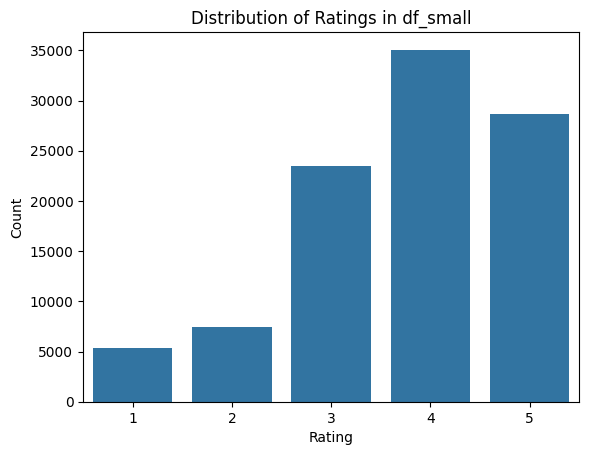

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='rating', data=df_small)
plt.title('Distribution of Ratings in df_small')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

Therefore we handle this by
* Sampling Weights
* Stratified sampling

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

def compute_class_weights(y):
    """Compute balanced class weights"""
    classes = np.unique(y)
    weights = compute_class_weight('balanced', classes=classes, y=y)
    return dict(zip(classes, weights))


def get_sample_weights(y):
    """Get per-sample weights based on class"""
    class_weights = compute_class_weights(y)
    return np.array([class_weights[label] for label in y])


def get_stratified_cv(n_splits=5, random_state=42):
    """Get stratified K-fold cross-validator"""
    return StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

# Merging Prepreprocessing Pipelines

## Sub-pipelines

In [ ]:
from sklearn.pipeline import Pipeline, FeatureUnion


def create_text_missing_pipeline(text_columns):
    """Pipeline for handling missing values in text columns"""
    return Pipeline([
        ('select_text', ColumnSelector(text_columns)),
        ('fill_missing', TextMissingHandler(fill_value=''))
    ])


def create_categorical_missing_pipeline(cat_columns):
    """Pipeline for handling missing values in categorical columns"""
    return Pipeline([
        ('select_categorical', ColumnSelector(cat_columns)),
        ('fill_missing', CategoricalMissingHandler(fill_value='Unknown'))
    ])


def create_numerical_missing_pipeline(num_columns):
    """Pipeline for handling missing values in numerical columns"""
    return Pipeline([
        ('select_numerical', ColumnSelector(num_columns)),
        ('fill_missing', NumericalMissingHandler(add_indicator=True))
    ])


def create_text_cleaning_pipeline(text_columns):
    """Pipeline for cleaning text"""
    return Pipeline([
        ('select_text', ColumnSelector(text_columns)),
        ('clean', TextCleaner(keep_negations=True, lowercase=True))
    ])


def create_text_feature_pipeline(text_columns):
    """Pipeline for extracting text features"""
    return FeatureUnion([
        ('length_features', Pipeline([
            ('select', ColumnSelector(text_columns)),
            ('extract', TextLengthFeatures())
        ])),
        ('sentiment_features', Pipeline([
            ('select', ColumnSelector(text_columns)),
            ('extract', TextSentimentFeatures())
        ])),
        ('keyword_features', Pipeline([
            ('select', ColumnSelector(text_columns)),
            ('extract', TextKeywordFeatures())
        ])),
        ('punctuation_features', Pipeline([
            ('select', ColumnSelector(text_columns)),
            ('extract', TextPunctuationFeatures())
        ]))
    ])


def create_tfidf_pipeline(text_column, max_features=500):
    """Pipeline for TF-IDF features for a single text column"""
    return Pipeline([
        ('select', FunctionTransformer(
            lambda X: X[text_column].fillna('').values,
            validate=False
        )),
        ('tfidf', TfidfVectorizer(
            max_features=max_features,
            ngram_range=(1, 2),
            min_df=1,
            max_df=0.98,
            sublinear_tf=True
        ))
    ])


def create_categorical_encoding_pipeline(cat_columns, strategy='both'):
    """Pipeline for encoding categorical variables"""
    if strategy == 'frequency':
        return Pipeline([
            ('select', ColumnSelector(cat_columns)),
            ('encode', FrequencyEncoder())
        ])
    elif strategy == 'target':
        return Pipeline([
            ('select', ColumnSelector(cat_columns)),
            ('encode', TargetEncoder(smoothing=1.0))
        ])
    elif strategy == 'both':
        return FeatureUnion([
            ('frequency', Pipeline([
                ('select', ColumnSelector(cat_columns)),
                ('encode', FrequencyEncoder())
            ])),
            ('target', Pipeline([
                ('select', ColumnSelector(cat_columns)),
                ('encode', TargetEncoder(smoothing=1.0))
            ]))
        ])
    else:
        raise ValueError(f"Unknown strategy: {strategy}")


def create_temporal_pipeline(year_column):
    """Pipeline for temporal feature extraction"""
    return Pipeline([
        ('select', ColumnSelector([year_column])),
        ('extract', TemporalFeatureExtractor())
    ])

## Master pipeline

In [ ]:
class MasterFeaturePipeline(BaseEstimator, TransformerMixin):
    """
    Master pipeline that composes all sub-pipelines
    This is the industry-standard way to build modular ML pipelines
    """
    def __init__(self, text_cols, cat_cols, num_cols):
        self.text_cols = text_cols
        self.cat_cols = cat_cols
        self.num_cols = num_cols

        # Initialize all sub-pipelines
        self.text_missing_pipeline = create_text_missing_pipeline(text_cols)
        self.cat_missing_pipeline = create_categorical_missing_pipeline(cat_cols)
        self.num_missing_pipeline = create_numerical_missing_pipeline(num_cols)

        self.text_cleaning_pipeline = None  # Will be created after missing handling
        self.text_feature_pipeline = None
        self.cat_encoding_pipeline = create_categorical_encoding_pipeline(cat_cols, strategy='both')
        self.temporal_pipeline = create_temporal_pipeline(num_cols[0]) if num_cols else None

        # TF-IDF pipelines (one per text column)
        self.tfidf_pipelines = {}

        self.fitted_ = False

    def fit(self, X, y=None):
        """Fit all sub-pipelines"""
        X_processed = X.copy()

        # Step 1: Handle missing values
        print("Step 1: Handling missing values...")
        text_data = self.text_missing_pipeline.fit_transform(X_processed)
        cat_data = self.cat_missing_pipeline.fit_transform(X_processed)
        num_data = self.num_missing_pipeline.fit_transform(X_processed)

        # Merge back
        X_processed[self.text_cols] = text_data
        X_processed[self.cat_cols] = cat_data
        for col in self.num_cols:
            X_processed[col] = num_data[col]
            if f'{col}_missing' in num_data.columns:
                X_processed[f'{col}_missing'] = num_data[f'{col}_missing']

        # Step 2: Clean text
        print("Step 2: Cleaning text...")
        self.text_cleaning_pipeline = create_text_cleaning_pipeline(self.text_cols)
        text_clean = self.text_cleaning_pipeline.fit_transform(X_processed)
        X_processed[self.text_cols] = text_clean

        # Step 3: Extract text features
        print("Step 3: Extracting text features...")
        self.text_feature_pipeline = create_text_feature_pipeline(self.text_cols)
        # This returns a tuple of DataFrames from FeatureUnion, we need to handle it

        # Step 4: Encode categorical
        print("Step 4: Encoding categorical variables...")
        self.cat_encoding_pipeline.fit(X_processed, y)

        # Step 5: Extract temporal features
        if self.temporal_pipeline:
            print("Step 5: Extracting temporal features...")
            self.temporal_pipeline.fit(X_processed)


        print("Step 6: Fitting TF-IDF pipelines...")
        for col in self.text_cols:
            # DEBUG: Check the text before TF-IDF
            sample_texts = X_processed[col].head(20).tolist()
            print(f"\n{col} sample texts after cleaning:")
            print(sample_texts)
            print(f"{col} unique values: {X_processed[col].nunique()}")
            print(f"{col} empty strings: {(X_processed[col] == '').sum()}")

            max_feat = 300 if col == 'headline' else 500
            self.tfidf_pipelines[col] = create_tfidf_pipeline(col, max_features=max_feat)
            self.tfidf_pipelines[col].fit(X_processed)

        self.fitted_ = True
        return self

    def transform(self, X):
        """Transform using all fitted sub-pipelines"""
        if not self.fitted_:
            raise ValueError("Pipeline must be fitted before transform")

        X_processed = X.copy()

        # Step 1: Handle missing values
        text_data = self.text_missing_pipeline.transform(X_processed)
        cat_data = self.cat_missing_pipeline.transform(X_processed)
        num_data = self.num_missing_pipeline.transform(X_processed)

        X_processed[self.text_cols] = text_data
        X_processed[self.cat_cols] = cat_data
        for col in self.num_cols:
            X_processed[col] = num_data[col]
            if f'{col}_missing' in num_data.columns:
                X_processed[f'{col}_missing'] = num_data[f'{col}_missing']

        # Step 2: Clean text
        text_clean = self.text_cleaning_pipeline.transform(X_processed)
        X_processed[self.text_cols] = text_clean

        # Step 3: Extract text features (manually combine FeatureUnion outputs)
        text_length = TextLengthFeatures().fit_transform(X_processed[self.text_cols])
        text_sentiment = TextSentimentFeatures().fit_transform(X_processed[self.text_cols])
        text_keywords = TextKeywordFeatures().fit_transform(X_processed[self.text_cols])
        text_punct = TextPunctuationFeatures().fit_transform(X_processed[self.text_cols])

        # Step 4: Encode categorical
        cat_encoded = self.cat_encoding_pipeline.transform(X_processed)
        # cat_encoded is tuple from FeatureUnion
        if isinstance(cat_encoded, tuple):
            cat_freq = pd.DataFrame(cat_encoded[0], index=X_processed.index)
            cat_target = pd.DataFrame(cat_encoded[1], index=X_processed.index)
            cat_features = pd.concat([cat_freq, cat_target], axis=1)
        else:
            cat_features = pd.DataFrame(cat_encoded, index=X_processed.index)

        # Step 5: Temporal features
        temporal_features = None
        if self.temporal_pipeline:
            temporal_features = self.temporal_pipeline.transform(X_processed)

        # Combine all features
        feature_dfs = [text_length, text_sentiment, text_keywords, text_punct,
                      cat_features]
        if temporal_features is not None:
            feature_dfs.append(temporal_features)

        # Add numerical features
        num_feature_cols = self.num_cols + [f'{col}_missing' for col in self.num_cols]
        num_features = X_processed[[col for col in num_feature_cols if col in X_processed.columns]]
        feature_dfs.append(num_features)

        features_combined = pd.concat(feature_dfs, axis=1)

        # Store for TF-IDF access
        self.processed_data_ = X_processed

        return features_combined

    def get_tfidf_features(self, X):
        """Get TF-IDF features separately (they're sparse matrices)"""
        tfidf_features = {}
        for col, pipeline in self.tfidf_pipelines.items():
            tfidf_features[col] = pipeline.transform(X)
        return tfidf_features

## Master Pipeline w/ Class Imbalance Handling


In [ ]:
def preprocessing_pipeline(df_train, df_test=None):
    """
    Main data preparation function using modular pipeline architecture
    """
    # Define column groups
    text_cols = ['pros', 'cons', 'headline']
    cat_cols = ['firm', 'job_title']
    num_cols = ['year_review']

    # Separate target
    y_train = df_train['rating'].values - 1  # Convert to 0-indexed
    X_train = df_train.drop('rating', axis=1)

    # Create master pipeline
    print("Creating modular pipeline...")
    pipeline = MasterFeaturePipeline(
        text_cols=text_cols,
        cat_cols=cat_cols,
        num_cols=num_cols
    )

    # Fit and transform training data
    print("\nFitting pipeline on training data...")
    X_train_features = pipeline.fit_transform(X_train, y_train)

    # Get TF-IDF features
    print("\nExtracting TF-IDF features...")
    tfidf_train = pipeline.get_tfidf_features(pipeline.processed_data_)

    # Process test data if provided
    X_test_features = None
    tfidf_test = None
    if df_test is not None:
        print("\nTransforming test data...")
        X_test_features = pipeline.transform(df_test)
        tfidf_test = pipeline.get_tfidf_features(pipeline.processed_data_)

    # Compute class weights
    class_weights = compute_class_weights(y_train)

    print(f"\nTraining features shape: {X_train_features.shape}")
    print(f"Class distribution: {np.bincount(y_train)}")
    print(f"Class weights: {class_weights}")

    # Convert to numpy
    X_train_numeric = X_train_features.select_dtypes(include=[np.number]).values

    results = {
        'X_train': X_train_numeric,
        'y_train': y_train,
        'X_train_df': X_train_features,  # Keep DataFrame for inspection
        'tfidf_train': tfidf_train,
        'pipeline': pipeline,
        'class_weights': class_weights
    }

    if df_test is not None:
        X_test_numeric = X_test_features.select_dtypes(include=[np.number]).values
        results['X_test'] = X_test_numeric
        results['X_test_df'] = X_test_features
        results['tfidf_test'] = tfidf_test
        print(f"Test features shape: {X_test_features.shape}")

    return results

# Model

We will be stacking our models.

The models we will choose to stack have to be good with non-linear text (as it's dealing with text embeddings) and be able to weigh classes.

Therefore I choose
* LightGBM - fast, handles class weights & categorical features well
* XGBoost - more extensive, also handles class weights well
* Random Forest - can also handle class weights

And for the meta-learner we use

* Logistic Regression - can also handle class weights


## Model Setup

### Configs

In [ ]:
from scipy.sparse import hstack, csr_matrix
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.calibration import CalibratedClassifierCV
import lightgbm as lgb
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

class Config:
    """Centralized configuration"""
    RANDOM_STATE = 42
    N_SPLITS = 5
    TEST_SIZE = 0.2

    # Model hyperparameters
    LGB_PARAMS = {
        'n_estimators': 300,
        'learning_rate': 0.05,
        'num_leaves': 20,
        'max_depth': -1,
        'class_weight': 'balanced',
        'random_state': RANDOM_STATE,
        'verbose': -1,
        'n_jobs': -1
    }

    XGB_PARAMS = {
        'n_estimators': 300,
        'learning_rate': 0.05,
        'max_depth': 4,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'random_state': RANDOM_STATE,
        'n_jobs': -1,
        'tree_method': 'hist'
    }

### Helper Functions

In [ ]:
import joblib
import os

def combine_features(X_numeric, tfidf_dict):
    """Combine numeric features with TF-IDF sparse matrices"""
    return hstack([
        csr_matrix(X_numeric),
        tfidf_dict['pros'],
        tfidf_dict['cons'],
        tfidf_dict['headline']
    ])


def get_sample_weights(y, class_weights):
    """Get per-sample weights from class weights dict"""
    return np.array([class_weights[label] for label in y])


def print_metrics(y_true, y_pred, title="Metrics"):
    """Print comprehensive metrics"""
    print(f"\n{'='*80}")
    print(f"{title}")
    print(f"{'='*80}")

    acc = accuracy_score(y_true, y_pred)
    print(f"Accuracy: {acc:.4f}")

    print("\nClassification Report:")
    print(classification_report(
        y_true, y_pred,
        target_names=['1-star', '2-star', '3-star', '4-star', '5-star'],
        digits=4
    ))

    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_true, y_pred)
    print(cm)

    print("\nPer-class Accuracy:")
    class_acc = cm.diagonal() / cm.sum(axis=1)
    for i, acc in enumerate(class_acc):
        print(f"  Class {i+1}: {acc:.4f}")

    return acc



class Checkpoint:
    @staticmethod
    def save(obj, path):
        os.makedirs(os.path.dirname(path), exist_ok=True)
        joblib.dump(obj, path)
        print(f"[Saved] {path}")

    @staticmethod
    def load(path):
        if os.path.exists(path):
            print(f"[Loaded] {path}")
            return joblib.load(path)
        return None

### Model Definitions

In [ ]:
def get_base_models():
    """Get dictionary of base models"""
    return {
        'lgb': lgb.LGBMClassifier(**Config.LGB_PARAMS),
        'xgb': xgb.XGBClassifier(**Config.XGB_PARAMS)
    }


def get_stacking_ensemble():
    """Get stacking ensemble model"""
    base_estimators = [
        ('lgb', lgb.LGBMClassifier(**Config.LGB_PARAMS)),
        ('xgb', xgb.XGBClassifier(**Config.XGB_PARAMS))
    ]

    meta_learner = LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=Config.RANDOM_STATE
    )

    return StackingClassifier(
        estimators=base_estimators,
        final_estimator=meta_learner,
        cv=Config.N_SPLITS,
        n_jobs=-1
    )

### Training

In [ ]:
ROUND_LIMIT = 30

class TrainingPipeline:
    """Handles all training, validation, and analysis on df_small"""

    def __init__(self, df_small):
        self.df_small = df_small
        self.results = None
        self.best_model_name = None
        self.best_model = None
        self.cache_dir = "checkpoints"

    def prepare_data(self):
        cache_path = f"{self.cache_dir}/prepared_data.pkl"
        cached = Checkpoint.load(cache_path)

        if cached:
            print("Loaded cached preprocessed features.")
            (self.X_train, self.y_train, self.class_weights,
             self.preprocessing_pipeline) = cached
            return self

        # otherwise, run full preprocessing
        results = preprocessing_pipeline(self.df_small, df_test=None)
        X_train = results['X_train']
        y_train = results['y_train']
        tfidf_train = results['tfidf_train']
        class_weights = results['class_weights']
        pipeline = results['pipeline']

        # Combine features
        X_train_full = combine_features(X_train, tfidf_train)

        # Save checkpoint
        Checkpoint.save((X_train_full, y_train, class_weights), cache_path)


        self.X_train = X_train_full
        self.y_train = y_train
        self.class_weights = class_weights
        self.preprocessing_pipeline = pipeline

        return self  # <- kept only ONE of these



    def train_individual_models(self):
        cache_path = f"{self.cache_dir}/trained_models.pkl"
        cached = Checkpoint.load(cache_path)

        if cached:
            print("Loaded cached trained models.")
            self.results = cached
            return self

        models = get_base_models()
        self.results = {}

        for name, model in models.items():
            print(f"\n--- Training {name.upper()} ---")

            # Special handling for XGBoost (needs sample weights)
            if name == 'xgb':
                sample_weights = get_sample_weights(self.y_train, self.class_weights)
                model.fit(self.X_train, self.y_train, sample_weight=sample_weights)
            else:
                model.fit(self.X_train, self.y_train)

            # Predict
            y_pred = model.predict(self.X_train)
            acc = accuracy_score(self.y_train, y_pred)

            self.results[name] = {
                "model": model,
                "train_acc": acc
            }

        Checkpoint.save(self.results, cache_path)
        return self


    def cross_validate_models(self):
        """Perform stratified K-fold cross-validation"""
        print("\n" + "="*80)
        print(f"STRATIFIED {Config.N_SPLITS}-FOLD CROSS-VALIDATION")
        print("="*80)

        skf = StratifiedKFold(
            n_splits=Config.N_SPLITS,
            shuffle=True,
            random_state=Config.RANDOM_STATE
        )

        cv_results = {}

        for name in self.results.keys():
            print(f"\n--- {name.upper()} Cross-Validation ---")

            fold_scores = []

            for fold, (train_idx, val_idx) in enumerate(skf.split(self.X_train, self.y_train), 1):
                X_tr = self.X_train[train_idx]
                X_val = self.X_train[val_idx]
                y_tr = self.y_train[train_idx]
                y_val = self.y_train[val_idx]

                # Clone model
                if name == 'lgb':
                    model = lgb.LGBMClassifier(**Config.LGB_PARAMS)
                elif name == 'xgb':
                    model = xgb.XGBClassifier(**Config.XGB_PARAMS)
                else:
                    model = RandomForestClassifier(**Config.RF_PARAMS)

                # Train
                if name == 'xgb':
                    sample_weights = get_sample_weights(y_tr, self.class_weights)
                    model.fit(X_tr, y_tr, sample_weight=sample_weights)
                else:
                    model.fit(X_tr, y_tr)

                # Evaluate
                y_pred = model.predict(X_val)
                acc = accuracy_score(y_val, y_pred)
                fold_scores.append(acc)

                print(f"  Fold {fold}: {acc:.4f}")

            mean_acc = np.mean(fold_scores)
            std_acc = np.std(fold_scores)

            print(f"  Mean CV Accuracy: {mean_acc:.4f} (+/- {std_acc:.4f})")

            cv_results[name] = {
                'scores': fold_scores,
                'mean': mean_acc,
                'std': std_acc
            }

            self.results[name]['cv_mean'] = mean_acc
            self.results[name]['cv_std'] = std_acc

        return self


    def train_ensemble(self):
        cache_path = f"{self.cache_dir}/ensemble.pkl"
        cached = Checkpoint.load(cache_path)

        if cached:
            print("Loaded cached ensemble.")
            self.results['ensemble'] = cached   # <- DOES NOT overwrite whole dict
            return self

        stacking_model = get_stacking_ensemble()
        print(f"Fitting ensemble...")
        print(f"{'='*80}")
        stacking_model.fit(self.X_train, self.y_train)

        y_pred = stacking_model.predict(self.X_train)
        train_acc = accuracy_score(self.y_train, y_pred)

        self.results['ensemble'] = {
            'model': stacking_model,
            'train_acc': train_acc
        }
        print(f"Ensemble train accuracy: {train_acc:.4f}")

        Checkpoint.save(self.results['ensemble'], cache_path)
        return self


    def summarize_results(self):
        """Print summary of all results"""
        print("\n" + "="*80)
        print("RESULTS SUMMARY")
        print("="*80)

        print("\nModel Performance (CV Accuracy):")
        print("-" * 60)
        print(f"{'Model':<20} {'Mean CV Acc':<15} {'Std Dev':<15}")
        print("-" * 60)

        for name, res in self.results.items():
            if 'cv_mean' in res:
                print(f"{name:<20} {res['cv_mean']:.4f}          {res['cv_std']:.4f}")

        # Find best model
        best_name = max(
            [k for k in self.results.keys() if 'cv_mean' in self.results[k]],
            key=lambda k: self.results[k]['cv_mean']
        )

        print("\n" + "="*80)
        print(f"BEST MODEL: {best_name.upper()}")
        print(f"CV Accuracy: {self.results[best_name]['cv_mean']:.4f} (+/- {self.results[best_name]['cv_std']:.4f})")
        print("="*80)

        self.best_model_name = best_name
        self.best_model = self.results[best_name]['model']

        return self

    def run_full_pipeline(self):
        """Run complete training pipeline"""
        return (self
                .prepare_data()
                .train_individual_models()
                .cross_validate_models()
                .train_ensemble()
                .summarize_results())


### Testing

In [ ]:
class TestingPipeline:
    """Handles final training on combined data and test predictions"""

    def __init__(self, df_small, df_large, df_test, model_name='ensemble'):
        self.df_small = df_small
        self.df_large = df_large
        self.df_test = df_test
        self.model_name = model_name

    def prepare_data(self):
        """Prepare combined training data and test data"""
        print("\n" + "="*80)
        print("FINAL DATA PREPARATION")
        print("="*80)

        df_combined = pd.concat([self.df_small, self.df_large],
                                axis=0, ignore_index=True)

        results = preprocessing_pipeline(df_combined, self.df_test)

        X_train = results['X_train']
        y_train = results['y_train']
        tfidf_train = results['tfidf_train']
        class_weights = results['class_weights']

        X_test = results['X_test']
        tfidf_test = results['tfidf_test']

        self.X_train_full = combine_features(X_train, tfidf_train)
        self.X_test_full = combine_features(X_test, tfidf_test)
        self.y_train = y_train
        self.class_weights = class_weights

        return self

    def train_final_model(self):
        """Train final model on all available data"""
        print("\n" + "="*80)
        print(f"TRAINING FINAL MODEL: {self.model_name.upper()}")
        print("="*80)

        # Only change needed: stacking ensemble uses K-fold internally
        if self.model_name == 'ensemble':
            model = get_stacking_ensemble()
        elif self.model_name == 'lgb':
            model = lgb.LGBMClassifier(**Config.LGB_PARAMS)
        elif self.model_name == 'xgb':
            model = xgb.XGBClassifier(**Config.XGB_PARAMS)
        else:
            raise ValueError(f"Unknown model: {self.model_name}")

        if self.model_name == 'xgb':
            sample_weights = get_sample_weights(self.y_train, self.class_weights)
            model.fit(self.X_train_full, self.y_train, sample_weight=sample_weights)
        else:
            model.fit(self.X_train_full, self.y_train)

        self.final_model = model
        return self

    def predict_test(self):
        """Make predictions on test set"""
        print("\n" + "="*80)
        print("PREDICTING TEST SET")
        print("="*80)

        y_test_pred = self.final_model.predict(self.X_test_full)

        # Convert 0–4 back to 1–5
        self.predictions = y_test_pred + 1
        return self

    def save_predictions(self, filename='predictions.csv'):
        submission = pd.DataFrame({'rating': self.predictions})
        submission.to_csv(filename, index=False)
        return self

    def run_full_pipeline(self, output_file='predictions.csv'):
        return (self
                .prepare_data()
                .train_final_model()
                .predict_test()
                .save_predictions(output_file))


## Model Workflow

In [ ]:
# Load data
print("="*80)
print("LOADING DATA")
print("="*80)

df_small = pd.read_csv(small_csv_file_path)
df_large = pd.read_csv(large_csv_file_path)
df_test = pd.read_csv(test_csv_file_path)

print(f"df_small: {df_small.shape}")
print(f"df_large: {df_large.shape}")
print(f"df_test: {df_test.shape}")

print("\n\n")
print("#" * 80)
print("# SECTION 1: TRAINING AND ANALYSIS")
print("#" * 80)

trainer = TrainingPipeline(df_small)
trainer.run_full_pipeline()

LOADING DATA
df_small: (100000, 7)
df_large: (500000, 7)
df_test: (100000, 7)



################################################################################
# SECTION 1: TRAINING AND ANALYSIS
################################################################################
Creating modular pipeline...

Fitting pipeline on training data...
Step 1: Handling missing values...
Step 2: Cleaning text...
Step 3: Extracting text features...
Step 4: Encoding categorical variables...
Step 5: Extracting temporal features...
Step 6: Fitting TF-IDF pipelines...

pros sample texts after cleaning:
['staff discount and part time work', 'employee training good people and promotes within', 'good reward nice office good wage opportunity for growth', 'straight forward work with school', 'quite an interesting job and opportunity for training in various area of the business', 'very good work enviroment and coleagues', 'good reliable honest hard worker', 'predictable good benefit not_hectic at all', 'fle

# Prediction

In [ ]:
print("\n\n")
print("#" * 80)
print("# SECTION 2: FINAL TESTING")
print("#" * 80)

# Use the best model from training
# Or manually specify: 'ensemble', 'lgb', 'xgb', 'rf'
best_model = trainer.best_model_name

tester = TestingPipeline(df_small, df_large, df_test, model_name=best_model)
tester.run_full_pipeline(output_file='predictions.csv')

print("\n\n")
print("#" * 80)
print("# WORKFLOW COMPLETE!")
print("#" * 80)
print(f"\nBest model from training: {best_model}")
print("Final predictions saved to: predictions.csv")




################################################################################
# SECTION 2: FINAL TESTING
################################################################################

FINAL DATA PREPARATION
Creating modular pipeline...

Fitting pipeline on training data...
Step 1: Handling missing values...
Step 2: Cleaning text...
Step 3: Extracting text features...
Step 4: Encoding categorical variables...
Step 5: Extracting temporal features...
Step 6: Fitting TF-IDF pipelines...

pros sample texts after cleaning:
['staff discount and part time work', 'employee training good people and promotes within', 'good reward nice office good wage opportunity for growth', 'straight forward work with school', 'quite an interesting job and opportunity for training in various area of the business', 'very good work enviroment and coleagues', 'good reliable honest hard worker', 'predictable good benefit not_hectic at all', 'flexible friendly interesting impactful collaborative', 'personal